### t2b1 — one round of train and eval

A 1D convolutional autoencoder is trained **only on healthy windows**. It never sees a
fault label during training. At evaluation, the per-window reconstruction error becomes
the anomaly score: the model reconstructs what it has seen before, so a bearing that
starts to spall reconstructs badly.

`t2b1` is the outer-race failure in test 2 — the clearest degradation ramp of the four,
starting around two thirds of the way through its life.

Parameters below are a first guess, not tuned.

In [1]:
import os

os.chdir('..')
os.getcwd()

'c:\\Users\\chouybat\\repositories\\phm-101'

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from loguru import logger

from phm_101.data_pipeline.data_extractor import DataExtractor
from phm_101.data_pipeline.data_loader import DataLoader
from phm_101.data_pipeline.data_transformer import DataTransformer
from phm_101.data_types.models import AutoencoderConfig, TrainConfig
from phm_101.ml_pipeline.eval_pipeline import Evaluator
from phm_101.ml_pipeline.train_pipeline import Trainer
from phm_101.models.autoencoder_conv1d import ConvAutoencoder1d

logger.remove()
torch.manual_seed(0)

CHANNEL = 't2b1'
WINDOW_SIZE = 2048  # ~3.4 shaft revolutions at 2000 rpm / 20 kHz
HOP = 2048  # no overlap: 10 windows tile a snapshot exactly
BATCH_SIZE = 256

model_config = AutoencoderConfig(
    window_size=WINDOW_SIZE,
    channels=(16, 32, 64, 128),
    kernel_size=7,
    latent_dim=32,
    batch_norm=True,
    dropout=0.0,
)
train_config = TrainConfig(
    epochs=30, learning_rate=1e-3, patience=5, grad_clip=1.0
)

print(f'torch {torch.__version__} | cuda {torch.cuda.is_available()}')
print(f'bottleneck length {model_config.bottleneck_length} '
      f'over {model_config.n_blocks} blocks')

torch 2.13.0+cu126 | cuda True
bottleneck length 128 over 4 blocks


c:\Users\chouybat\repositories\phm-101\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### data pipeline

In [3]:
extractor = DataExtractor()
transformer = DataTransformer()
loader = DataLoader(window_size=WINDOW_SIZE, hop=HOP, batch_size=BATCH_SIZE)

data = extractor.load(CHANNEL)
split = transformer.train_test_split(data)
transformer.fit(split.train)  # statistics from train only

parts = {
    name: transformer.transform(getattr(split, name))
    for name in ['train', 'val', 'test']
}
loaders = {
    name: loader.get_dataloader(part, train=(name == 'train'))
    for name, part in parts.items()
}

pd.DataFrame([
    {
        'part': name,
        'snapshots': len(part),
        'windows': len(loaders[name].dataset),
        'faulty': int(part.labels.sum()),
        'from': part.timestamps[0],
        'to': part.timestamps[-1],
    }
    for name, part in parts.items()
])

,part,snapshots,windows,faulty,from,to
0,train,447,4470,0,2004-02-12 10:32:39,2004-02-15 12:52:39
1,val,111,1110,0,2004-02-15 13:02:39,2004-02-16 07:22:39
2,test,424,4240,280,2004-02-16 07:32:39,2004-02-19 06:02:39


Train and val are healthy by construction. Only the test split contains the fault.

### model

In [4]:
model = ConvAutoencoder1d(model_config)

probe = torch.randn(2, 1, WINDOW_SIZE)
print(f'in  {tuple(probe.shape)}')
print(f'latent {tuple(model.encode(probe).shape)}')
print(f'out {tuple(model(probe).shape)}')
print(f'parameters {sum(p.numel() for p in model.parameters()):,}')

assert model(probe).shape == probe.shape, 'autoencoder must preserve shape'

in  (2, 1, 2048)
latent (2, 32)
out (2, 1, 2048)
parameters 1,216,801


### train

training: 100%|██████████| 30/30 [00:05<00:00,  5.42it/s]


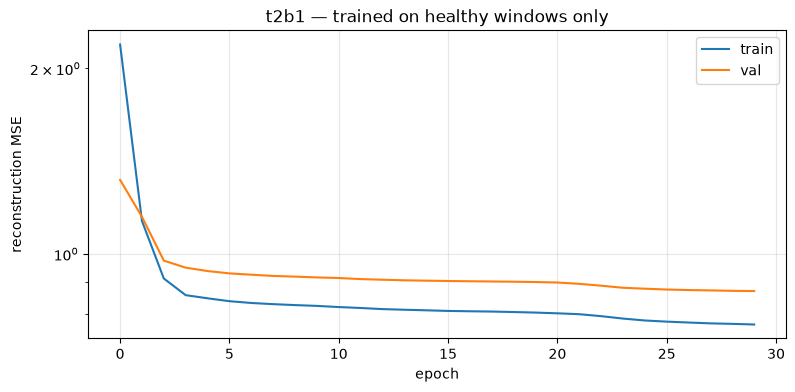

In [5]:
trainer = Trainer(model, train_config)
history = trainer.train(loaders['train'], loaders['val'])

plt.figure(figsize=(9, 4))
plt.plot(history['train_loss'], label='train')
plt.plot(history['val_loss'], label='val')
plt.xlabel('epoch')
plt.ylabel('reconstruction MSE')
plt.yscale('log')
plt.title(f'{CHANNEL} — trained on healthy windows only')
plt.legend()
plt.grid(alpha=0.3)

### evaluate

The alarm threshold is the 99th percentile of the **validation** scores — healthy data
the model was not trained on. The test labels are never used to pick it.

In [6]:
evaluator = Evaluator(trainer.model, aggregation='mean', quantile=0.99)
result = evaluator.evaluate(loaders['test'], loaders['val'])

pd.Series(result.metrics).to_frame('value').round(4)

,value
threshold,1.0801
fault_rate,0.6604
precision,0.6747
recall,1.0000
f1,0.8058
auroc,0.9627
average_precision,0.9826
detection_delay,0.0000


In [ ]:
timestamps = parts['test'].timestamps

scores, labels, threshold = result.scores, result.labels, result.threshold
alarm = scores > threshold

tp = int((alarm & (labels == 1)).sum())
fp = int((alarm & (labels == 0)).sum())
fn = int((~alarm & (labels == 1)).sum())
tn = int((~alarm & (labels == 0)).sum())
print(f'TP {tp}  FP {fp}  FN {fn}  TN {tn}')
print(f'healthy test snapshots flagged: {fp}/{fp + tn} = {100 * fp / (fp + tn):.0f}%')

# how much of the signal does the autoencoder actually reconstruct?
# the z-scored signal has variance 1, so predicting zeros gives MSE 1.0
explained = 1 - history['train_loss'][-1]
print()
print(f'variance explained by the reconstruction: {100 * explained:.0f}%')

first = int(np.argmax(alarm))
onset_index = int(np.argmax(labels == 1))
print()
print(f'test starts    {timestamps[0]}')
print(f'first alarm    {timestamps[first]}  (index {first})')
print(f'labelled onset {timestamps[onset_index]}  (index {onset_index})')
print(f'alarm precedes the label by {(onset_index - first) * 10 / 60:.1f} h')

`detection_delay` is in **snapshots**, one every 10 minutes, counted from the labelled
fault onset to the first alarm at or after it.

In [ ]:
onset = extractor.fault_onset[CHANNEL]

fig, axes = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

axes[0].scatter(
    timestamps, result.scores, c=result.labels, cmap='coolwarm', s=8
)
axes[0].axhline(result.threshold, ls='--', c='black', label='threshold')
axes[0].axvline(np.datetime64(onset), ls=':', c='green', label='labelled onset')
axes[0].set_yscale('log')
axes[0].set_ylabel('reconstruction error')
axes[0].set_title(f'{CHANNEL} — anomaly score over the test period')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(timestamps, (result.scores > result.threshold).astype(int), lw=1)
axes[1].plot(timestamps, result.labels, lw=1, ls='--')
axes[1].set_yticks([0, 1], ['healthy', 'faulty'])
axes[1].legend(['predicted', 'labelled'])
axes[1].grid(alpha=0.3)

fig.tight_layout()

In [ ]:
healthy = result.scores[result.labels == 0]
faulty = result.scores[result.labels == 1]

bins = np.logspace(
    np.log10(result.scores.min()), np.log10(result.scores.max()), 60
)
plt.figure(figsize=(9, 4))
plt.hist(healthy, bins=bins, alpha=0.6, label=f'healthy (n={len(healthy)})')
plt.hist(faulty, bins=bins, alpha=0.6, label=f'faulty (n={len(faulty)})')
plt.axvline(result.threshold, ls='--', c='black', label='threshold')
plt.xscale('log')
plt.xlabel('reconstruction error')
plt.title('score separation on the test split')
plt.legend()
plt.grid(alpha=0.3)

### what the numbers mean

**The ranking works, the operating point does not.** `auroc` 0.96 and
`average_precision` 0.98 say the score orders faulty snapshots above healthy ones
almost perfectly. But at the 99th-percentile threshold the model flags **136 of the
144 healthy test snapshots**, so `precision` 0.67 is barely above `fault_rate` 0.66 —
roughly what flagging everything would score. Recall is 1.0 for the same reason.

**The autoencoder reconstructs only about a quarter of the signal.** The z-scored
input has variance 1, so predicting zeros everywhere would give MSE 1.0; training
settles near 0.77. That is not a bug — raw vibration is broadband and phase-random, so
no small latent code can predict where the next peak lands. Anomaly detection still
works because the error *rises* when the signal changes character, not because the
reconstruction is good.

**The first alarm lands ~24 h before the labelled onset**, at the second snapshot of
the test split. Two readings, and this run cannot separate them:

1. genuine early detection — the bearing is already degrading before RMS and kurtosis
   cross the thresholds that set `fault_onset`;
2. a miscalibrated threshold — validation is the last healthy stretch the model was
   early-stopped on, so its scores are optimistically low and everything after clears
   the bar.

Reading 2 is the more likely of the two, since the alarm starts at essentially the
first test snapshot rather than ramping up. Worth checking before tuning: whether the
score rises gradually or steps up immediately at the train/test boundary.

Knobs to turn first, in order: `quantile` and `aggregation='max'` on the `Evaluator`
(cheap, no retraining), then `latent_dim` and `window_size`. Note the threshold rests
on only 111 validation snapshots, so its 99th percentile is effectively the second
largest value — a noisy estimate.